# Halvard QC failures and HaloCloud churn: walkthrough

This notebook walks through the analysis in the order it was done. It reads the outputs that the
scripts write, so it adds no new analysis and every number matches `output/stats.json`.

To regenerate the outputs, put the data pack in `data/raw/halvard_data_pack/`, then run
`python src/build.py`, `python src/analysis.py` and `python src/figures.py` from the repo root.

**p-value labels used throughout:** below 0.05 is *significant*; 0.05 to 0.25 is a *possible trend*;
above 0.25 means *we need more data*.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
OUT, TAB, FIG = ROOT / "output", ROOT / "output" / "tables", ROOT / "output" / "figures"
S = json.loads((OUT / "stats.json").read_text())
pd.set_option("display.precision", 3)

def table(name):
    return pd.read_csv(TAB / f"{name}.csv")

def facts(d, label="value"):
    # A result dictionary as a readable two-column table. [k, n] pairs are churned of sites.
    flat = pd.json_normalize(d, sep=" / ").T
    flat.columns = [label]
    fmt = lambda v: (f"{v[0]} of {v[1]} ({v[0]/v[1]:.1%})" if isinstance(v, list) and len(v) == 2 and v[1]
                     else round(v, 3) if isinstance(v, float) else v)
    display(flat.map(fmt))

def figure(name, width=820):
    # Embed a smaller copy of the committed figure, so the notebook stays small enough
    # for GitHub to render. The full-size PNG stays in output/figures.
    import io as _io
    from PIL import Image as _PIL
    im = _PIL.open(FIG / f"{name}.png").convert("RGB")
    im.thumbnail((1000, 3000))
    buf = _io.BytesIO()
    im.quantize(colors=64).save(buf, "PNG", optimize=True)
    display(Image(data=buf.getvalue(), width=width))

## 1. Data checks

Every check names its rule and where the rule comes from. Four checks fail on the data as delivered,
and each failure has an approved action. The biggest is 1,561 duplicate run IDs, where every copy is
identical in every column, so staging keeps one copy of each.

In [2]:
checks = (OUT / "checks.md").read_text()
display(Markdown(checks))

# Data checks

Zero failing rows means the check passes.

| Check | What it tests | Source of the rule | Failing rows | Result | Action |
|---|---|---|---|---|---|
| `sites_pk_unique` | Every site_id appears once in sites | Dictionary: site_id is the primary key | 0 | pass |  |
| `instruments_pk_unique` | Every instrument_id appears once | Dictionary: instrument_id is the primary key | 0 | pass |  |
| `raw_runs_duplicate_ids` | Every run_id appears once in the file as delivered | Dictionary: run_id is the primary key | 1561 | **FAIL** | Approved: stg_runs keeps one copy of each identical pair |
| `raw_runs_duplicates_identical` | Where a run_id repeats in the file, every copy is identical in every column | Diagnostic: tests the duplicate proposal | 0 | pass |  |
| `runs_pk_unique` | Every run_id appears once after staging | Dictionary: run_id is the primary key | 0 | pass |  |
| `events_pk_unique` | Every event_id appears once | Dictionary: event_id is the primary key | 0 | pass |  |
| `tickets_pk_unique` | Every ticket_id appears once | Dictionary: ticket_id is the primary key | 0 | pass |  |
| `subscriptions_one_per_site` | Each site has at most one subscription row | Dictionary: one row per site | 0 | pass |  |
| `every_site_has_subscription` | Every site has a subscription row | Dictionary: one row per site | 0 | pass |  |
| `instruments_site_fk` | Every instrument belongs to a known site | Dictionary: site_id is a foreign key to sites | 0 | pass |  |
| `runs_instrument_fk` | Every run belongs to a known instrument | Dictionary: instrument_id is a foreign key to instruments | 0 | pass |  |
| `events_site_fk` | Every app event belongs to a known site | Dictionary: site_id is a foreign key to sites | 0 | pass |  |
| `tickets_site_fk` | Every ticket belongs to a known site | Dictionary: site_id is a foreign key to sites | 0 | pass |  |
| `runs_firmware_known` | Every run's firmware is a published release | Inference: firmware_releases lists the published releases | 0 | pass |  |
| `region_values` | Region is one of the four documented values | Dictionary: listed values | 0 | pass |  |
| `segment_values` | Segment is one of the three documented values | Dictionary: listed values | 0 | pass |  |
| `model_values` | Model is HX-200 or HX-200 Plus | Dictionary: listed values | 0 | pass |  |
| `qc_status_values` | QC status is pass, fail or skipped | Dictionary: listed values | 0 | pass |  |
| `skipped_before_400` | No run on firmware before 4.0.0 records skipped | Dictionary: skipped arrived in firmware 4.0.0 | 0 | pass |  |
| `status_values` | Subscription status is active, notice or churned | Dictionary: listed values | 0 | pass |  |
| `tier_values` | Tier is Basic or Plus | Dictionary: listed values | 0 | pass |  |
| `runs_in_window` | Every run falls inside 2025-09-01 to 2026-08-31 UTC | Dictionary: extract window | 0 | pass |  |
| `events_in_window` | Every app event falls inside the window | Dictionary: extract window | 0 | pass |  |
| `tickets_in_window` | Every ticket opened inside the window | Dictionary: extract window | 0 | pass |  |
| `runs_after_install` | No run happens before its instrument was installed | Dictionary: install_date is the date the instrument was commissioned | 3 | **FAIL** | Approved: keep the runs, too few to move any rate |
| `tickets_resolve_after_open` | A resolved ticket closes after it opens | Logic | 12 | **FAIL** | Approved: keep the tickets, resolution_hours is blank for them |
| `runs_positive_values` | Sample count and duration are positive | Logic | 0 | pass |  |
| `churned_date_in_window` | A churned site's missed renewal falls inside the window | Inference: churn is observed at a renewal inside the window | 0 | pass |  |
| `active_date_after_extract` | An active or notice site's next renewal is after the extract date | Dictionary: renewal_date is the next renewal for active sites | 4 | **FAIL** | Approved: flag the sites (status_conflict) and leave them out of the churn comparison |
| `renewal_on_anniversary` | Renewal date falls on the start date's anniversary | Inference: HaloCloud is an annual subscription | 0 | pass |  |
| `mart_one_row_per_site` | site_renewal holds exactly one row for every site | Logic: the table is defined as one row per site | 0 | pass |  |
| `mart_rates_in_range` | Every rate and share falls between 0 and 1 | Logic | 0 | pass |  |
| `mart_runs_add_up` | QC pass, fail and skipped on 4.0.0 and later plus pre-4.0.0 runs equal all runs | Logic | 0 | pass |  |
| `mart_qc_rules_applied` | Main-cohort sites without a clean QC rate are exactly the ones the two approved rules leave out | Logic: approved QC comparison rules 1 and 2 | 0 | pass |  |


## 2. The site table

One row per site. Each site gets a **decision date**: the missed renewal for churned sites, and the
last renewal (next renewal minus 12 months) for active and notice sites. Everything about a site is
measured in the **90 days before** that date, so nothing after the decision leaks in.

- **Churn** means `status = churned`. The 9 `notice` sites have not reached their decision yet, so
  they are counted separately.
- **Main cohort:** 431 sites with a full 90 days of data before the decision.
- **Clean QC rate:** fail / (pass + fail) on firmware 4.0.0 and later. Older firmware records a
  skipped QC step as a fail.
- **Ran the affected firmware:** the site ran IA-Panel-3 on an HX-200 on 4.1.0 or 4.1.1 in its
  90-day window.

In [3]:
sites = table("sites_main")
display(sites.groupby("affected_exposure").agg(sites=("site_id", "size"), churned=("churn", "sum")))

,sites,churned
affected_exposure,,
no,295,32
yes,136,35


## 3. Firmware or a bad control lot?

The pack has no lot data, so the test uses what a lot problem must follow. A bad lot reaches every lab
that uses it in the same weeks. A firmware defect follows each instrument's own firmware version.

**Why these tests:**
- *Logistic regression with month and firmware:* if month adds nothing once firmware is in the model,
  a time-based cause such as a lot does not explain the failures. The likelihood-ratio test compares
  the models with and without month.
- *Two-proportion z-test:* compares failure rates on affected and other firmware in the same months.
- *Wilcoxon signed-rank test:* compares each instrument with itself before and after its own upgrade,
  so instrument differences cancel out.

Firmware odds ratio 19.4 (95% CI 16.6 to 22.8); month adds nothing (p = 0.91)
Before upgrade 271/1001 = 27.1%; after 41/1080 = 3.8%; 361 instruments; Wilcoxon p = 5.9e-17


,group,firmware,n,events,rate,ci_low,ci_high
0,HX-200 · IA-Panel-3,4.0.0,1346,31,0.023,0.016,0.033
1,HX-200 · IA-Panel-3,4.0.2,1348,49,0.036,0.028,0.048
2,HX-200 · IA-Panel-3,4.1.0,929,363,0.391,0.360,0.423
3,HX-200 · IA-Panel-3,4.1.1,520,215,0.413,0.372,0.456
4,HX-200 Plus · IA-Panel-3,4.1.0 or 4.1.1,474,19,0.040,0.026,0.062


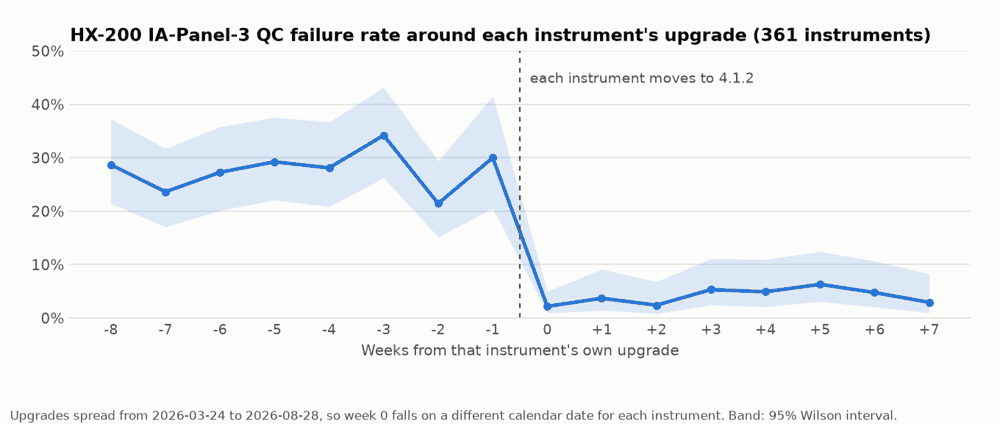

In [4]:
lm, le = S["lot_model"], S["lot_event_time"]
print(f"Firmware odds ratio {lm['firmware_odds_ratio']:.1f} "
      f"(95% CI {lm['firmware_or_ci'][0]:.1f} to {lm['firmware_or_ci'][1]:.1f}); month adds nothing (p = {lm['month_p']:.2f})")
print(f"Before upgrade {le['before'][0]}/{le['before'][1]} = {le['before'][0]/le['before'][1]:.1%}; "
      f"after {le['after'][0]}/{le['after'][1]} = {le['after'][0]/le['after'][1]:.1%}; "
      f"{le['instruments']} instruments; Wilcoxon p = {le['wilcoxon_p']:.1e}")
display(table("lot_same_window"))
figure("lot_test_event_time")

## 4. Adoption and failures

**Why this test:** a weighted linear regression of the weekly failure rate on the share of runs on
the affected firmware. If the defect drives the failures, the fleet rate rises and falls with that
share.

Weekly rate = 2.9% + 38% x share on affected firmware; R2 = 0.93


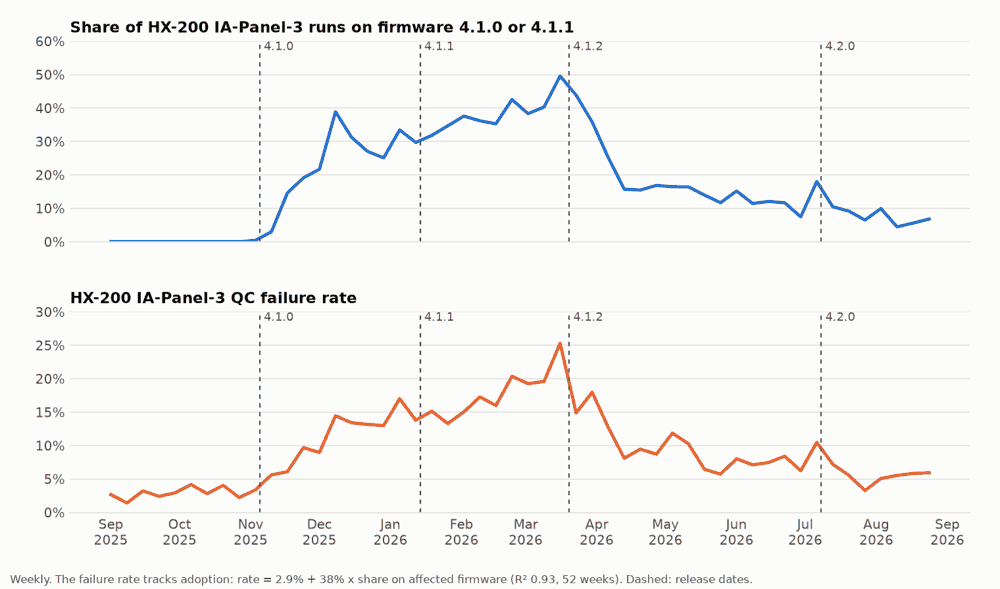

In [5]:
a = S["adoption"]
print(f"Weekly rate = {a['intercept']:.1%} + {a['slope']:.0%} x share on affected firmware; R2 = {a['r2']:.2f}")
figure("adoption_and_failures")

## 5. Churn comparison

**Why these methods:** comparison tables with 95% Wilson intervals come first, because a reader can
check them by eye. Logistic regression then holds region, segment, tier and run volume equal. App use
and tickets stay out of the main model, because they can sit on the path from failures to churn.

,affected_exposure,n,events,rate,ci_low,ci_high
0,no,295,32,0.108,0.078,0.149
1,yes,136,35,0.257,0.191,0.337


,term,odds_ratio,ci_low,ci_high,p_value
0,C(affected_exposure)[T.yes],2.285,1.283,4.072,0.005
1,"C(region, Treatment('NA-East'))[T.APAC]",1.327,0.525,3.354,0.551
2,"C(region, Treatment('NA-East'))[T.EU]",2.390,1.181,4.839,0.015
3,"C(region, Treatment('NA-East'))[T.NA-West]",0.632,0.264,1.515,0.304
4,C(segment)[T.reference_lab],0.517,0.216,1.238,0.139
5,C(segment)[T.research],2.898,1.419,5.919,0.003
6,C(tier)[T.Plus],0.877,0.482,1.595,0.667
7,log_runs,1.189,0.788,1.793,0.410


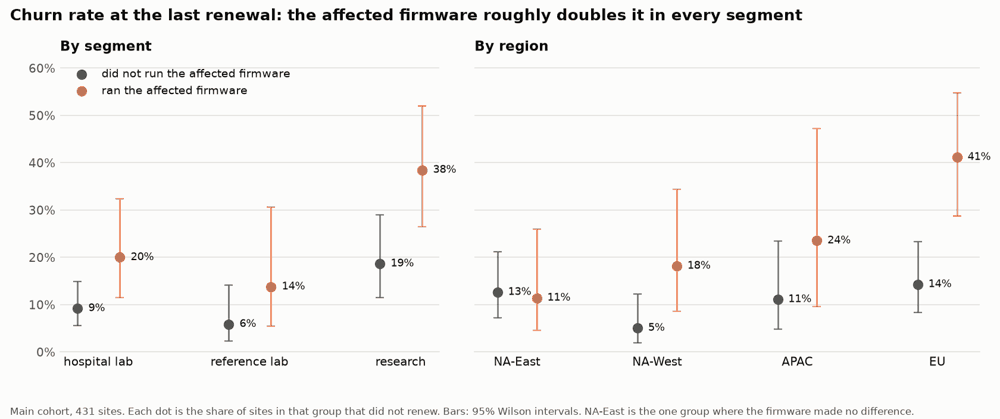

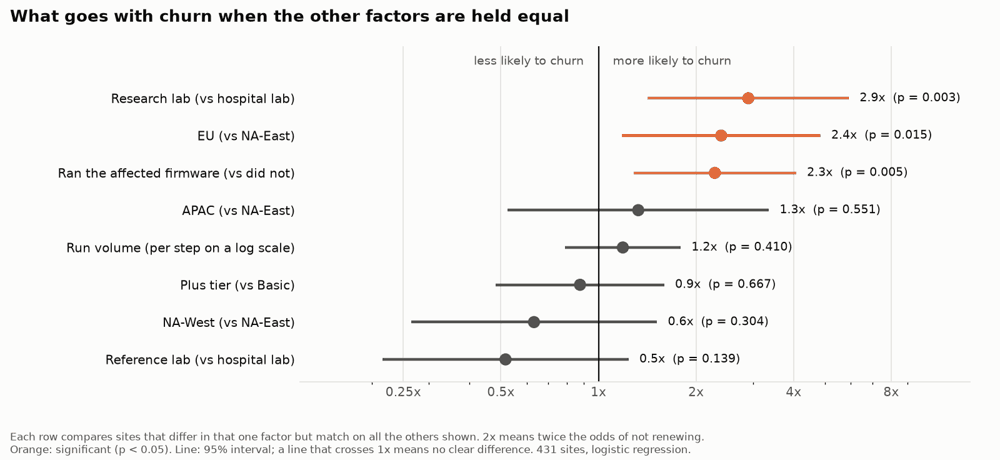

In [6]:
display(table("churn_by_affected_exposure"))
display(table("regression_exposure_no_mediators"))
figure("churn_by_segment_region")
figure("what_goes_with_churn")

## 6. Customer story

**Why this test:** the detection week uses a one-sided binomial test of each week's failures against
the 3.0% rate the same instruments and assay had on 4.0.x. A week counts as clear once p falls below
0.001 with at least 20 runs.

,value
release_410,2025-11-05
first_qc_rejection_ticket,2025-11-19
signal_clear_week,2025-11-24
fix_412,2026-03-20
days_signal_to_fix,116
exposed_sites,136
exposed_churned,35
exposed_churned_before_fix,23
excess_churned_sites,20.247
excess_arr,129294.479


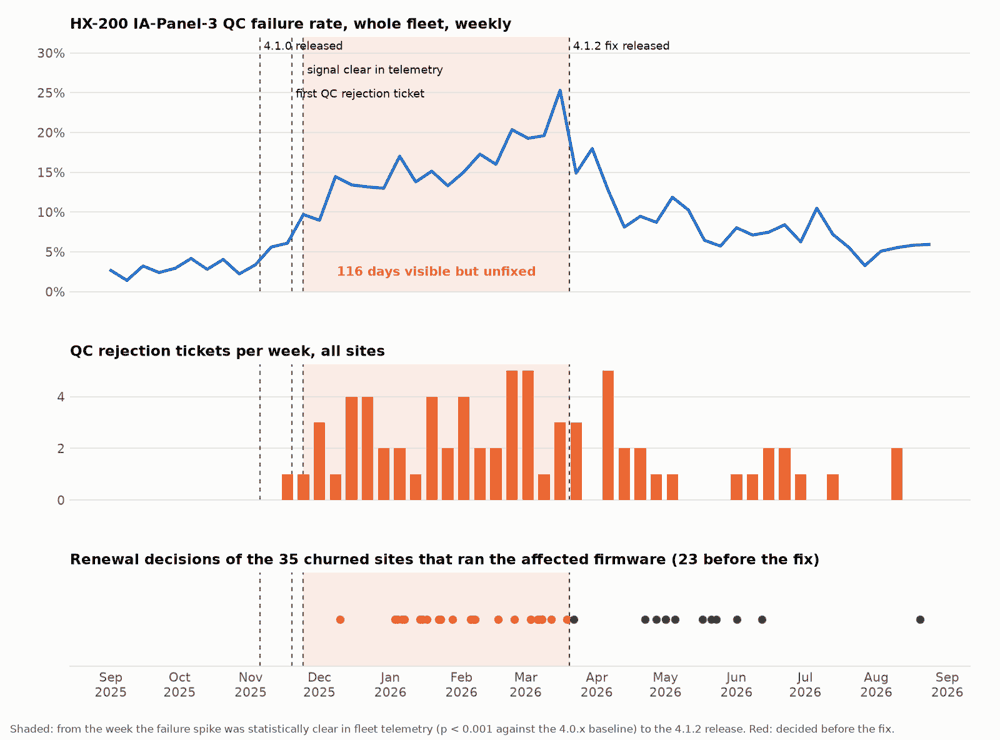

,week,n,fails,rate,p_vs_baseline
0,2025-11-03,1,0,0.000,1.000e+00
1,2025-11-10,6,2,0.333,1.253e-02
2,2025-11-17,34,5,0.147,3.314e-03
3,2025-11-24,37,17,0.459,1.217e-16
4,2025-12-01,48,16,0.333,4.073e-13
5,2025-12-08,95,30,0.316,1.565e-22


In [7]:
cs = S["customer_story"]
facts({k: str(cs[k])[:10] if "_4" in k or "ticket" in k or "week" in k else cs[k]
       for k in ["release_410", "first_qc_rejection_ticket", "signal_clear_week", "fix_412", "days_signal_to_fix",
                 "exposed_sites", "exposed_churned", "exposed_churned_before_fix", "excess_churned_sites", "excess_arr"]})
figure("visible_before_fixed")
display(table("detection_weekly"))

## 7. Follow-up checks

These are exploratory. The primary test is the exposure comparison in section 5.

**Europe.** *Mann-Whitney U* compares response times, which are skewed, by rank. *Fisher's exact
test* compares churn rates in small groups with an exact p-value.

,ticket_type,region_group,n,median,q25,q75
0,All other,"Direct (NA, APAC)",1962,6.2,3.70,10.50
1,All other,EU (distributor),905,17.8,11.10,28.80
2,QC rejection,"Direct (NA, APAC)",48,6.2,3.95,12.15
3,QC rejection,EU (distributor),23,22.8,10.30,34.45


,"Churn, ran the affected firmware: a = EU, b = direct"
a,21 of 51 (41.2%)
b,14 of 85 (16.5%)
odds_ratio,3.55
p,0.002


,Response time: churned vs renewed sites that filed a QC ticket
sites,31.000
churned,5.000
median_churned,14.800
median_renewed,9.825
mannwhitney_p,0.936


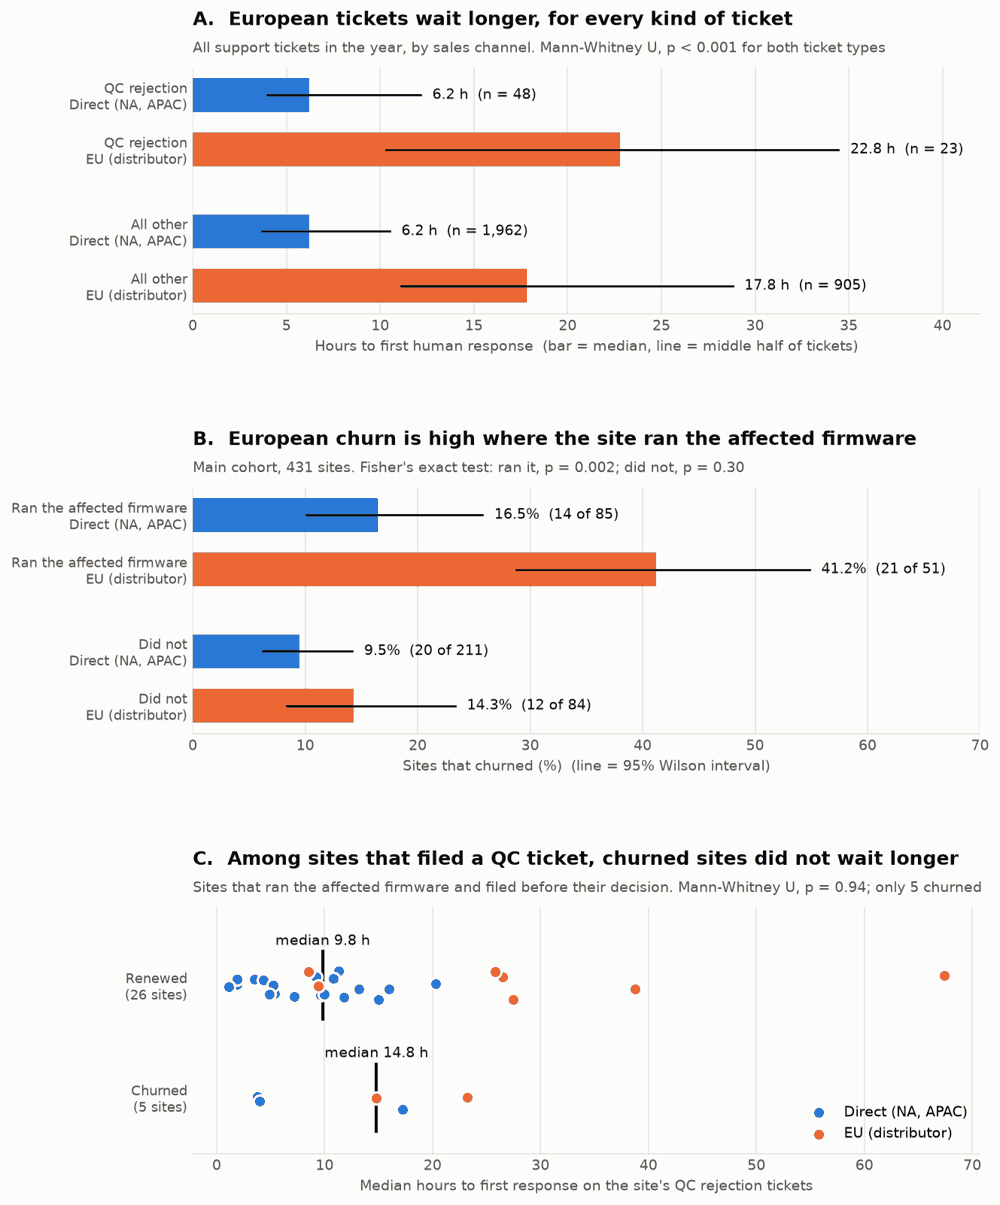

,region_group,segment,affected_exposure,n,events,rate,ci_low,ci_high
0,"Direct (NA, APAC)",hospital_lab,no,108,8,0.074,0.038,0.139
1,"Direct (NA, APAC)",hospital_lab,yes,37,7,0.189,0.095,0.342
2,"Direct (NA, APAC)",reference_lab,no,46,2,0.043,0.012,0.145
3,"Direct (NA, APAC)",reference_lab,yes,15,1,0.067,0.012,0.298
4,"Direct (NA, APAC)",research,no,57,10,0.175,0.098,0.294
5,"Direct (NA, APAC)",research,yes,33,6,0.182,0.086,0.344
6,EU (distributor),hospital_lab,no,44,6,0.136,0.064,0.267
7,EU (distributor),hospital_lab,yes,18,4,0.222,0.090,0.452
8,EU (distributor),reference_lab,no,22,2,0.091,0.025,0.278
9,EU (distributor),reference_lab,yes,14,3,0.214,0.076,0.476


In [8]:
eu = S["follow_ups"]["eu_channel"]
display(table("first_response_by_channel"))
facts(eu["exposed_churn_eu_vs_direct"], "Churn, ran the affected firmware: a = EU, b = direct")
facts(eu["response_churned_vs_renewed"], "Response time: churned vs renewed sites that filed a QC ticket")
figure("eu_support_churn")
display(table("churn_by_exposure_region_segment"))

**App use.** *Cochran-Mantel-Haenszel test:* compares sites that did and did not run the affected
firmware inside each third of HaloCloud use, then combines the three comparisons.

In [9]:
display(table("churn_by_exposure_and_app_use"))
facts(S["follow_ups"]["exposure_within_app_use"], "Ran the affected firmware, within app-use thirds")

,app_band,affected_exposure,n,events,rate,ci_low,ci_high
0,high,no,107,2,0.019,0.005,0.066
1,high,yes,27,1,0.037,0.007,0.183
2,low,no,76,21,0.276,0.188,0.386
3,low,yes,70,29,0.414,0.306,0.531
4,middle,no,112,9,0.080,0.043,0.146
5,middle,yes,39,5,0.128,0.056,0.267


,"Ran the affected firmware, within app-use thirds"
pooled_odds_ratio,1.819
cmh_p,0.042
equal_odds_p,0.987


**Decisions after the fix, a QC failure threshold, and European research labs.** All use Fisher's
exact test.

In [10]:
fu = S["follow_ups"]
facts(fu["decided_after_fix"], "Renewal after 4.1.2: a = ran it, b = did not")
facts(fu["qc_threshold_5pct"], "QC failure rate: a = above 5%, b = at or below")
facts(fu["eu_research_labs"], "European research labs: a = ran it, b = did not")

,"Renewal after 4.1.2: a = ran it, b = did not"
a,12 of 52 (23.1%)
b,14 of 99 (14.1%)
odds_ratio,1.821
p,0.18
sites_running_defect_after_fix,36
still_running_vs_upgraded / a,8 of 36 (22.2%)
still_running_vs_upgraded / b,4 of 16 (25.0%)
still_running_vs_upgraded / odds_ratio,0.857
still_running_vs_upgraded / p,1.0
still_running_vs_upgraded / median_days_run_after_fix,29.5


,"QC failure rate: a = above 5%, b = at or below"
all_sites / a,35 of 153 (22.9%)
all_sites / b,30 of 251 (12.0%)
all_sites / odds_ratio,2.185
all_sites / p,0.005
did_not_run_defect / a,10 of 59 (16.9%)
did_not_run_defect / b,20 of 209 (9.6%)
did_not_run_defect / odds_ratio,1.929
did_not_run_defect / p,0.158
ran_defect / a,25 of 94 (26.6%)
ran_defect / b,10 of 42 (23.8%)


,"European research labs: a = ran it, b = did not"
a,14 of 19 (73.7%)
b,4 of 18 (22.2%)
odds_ratio,9.8
p,0.003


**Normal churn and group-size limits.** Normal churn is the rate for sites that did not run the
affected firmware. A group breaches normal when its rate is above the center line plus 1.96 standard
errors for its size, so the limit widens for small groups.

In [11]:
facts(fu["churn_baseline"], "Normal churn")
display(table("churn_baseline_by_segment"))
display(table("churn_vs_baseline_limits"))
facts(fu["excess_arr_range"], "Excess ARR, three ways")

,Normal churn
normal,32 of 295 (10.8%)
rate,0.108
ci_low,0.078
ci_high,0.149
before_defect,8 of 56 (14.3%)
upper_limit_by_size / 50,0.195
upper_limit_by_size / 136,0.161
upper_limit_by_size / 300,0.144


,segment,n,events,rate,ci_low,ci_high
0,hospital_lab,152,14,0.092,0.056,0.149
1,reference_lab,68,4,0.059,0.023,0.142
2,research,75,14,0.187,0.115,0.289


,group,n,churned,rate,upper_limit,breach
0,Ran the affected firmware,136,35,0.257,0.161,True
1,"EU, ran the affected firmware",51,21,0.412,0.194,True
2,"All main-cohort renewals, 2025Q4",13,2,0.154,0.278,False
3,"All main-cohort renewals, 2026Q1",287,42,0.146,0.144,True
4,"All main-cohort renewals, 2026Q2",94,21,0.223,0.171,True
5,"All main-cohort renewals, 2026Q3",37,2,0.054,0.209,False
6,"Did not run the defect, 2025Q4",10,1,0.100,0.301,False
7,"Did not run the defect, 2026Q1",196,19,0.097,0.152,False
8,"Did not run the defect, 2026Q2",62,11,0.177,0.186,False
9,"Did not run the defect, 2026Q3",27,1,0.037,0.226,False


,"Excess ARR, three ways"
excess_sites,20.247
at_mean_arr_of_exposed_churned,129294.479
at_mean_arr_of_all_exposed,135255.995
churned_arr_minus_expected,124950.847


**The smallest group worth reporting.** A churn rate for a small group swings by chance. *Power
analysis with an exact binomial test* asks how many sites a group needs before its churn rate can
separate a real change from chance: a 5% false-alarm rate and an 80% chance of catching the change.
The one judgment is the size of change to catch. Catching churn at double normal takes about 82
sites, so a territory cut smaller than that gives sales numbers that chance alone can produce.

In [12]:
display(table("min_group_size"))
display(table("regions_vs_min_group_size"))

,change,churn_to_catch,sites_needed
0,1.5 times normal,0.163,269
1,double normal,0.217,82
2,the defect effect,0.257,47
3,triple normal,0.325,27


,region,sites,meets_minimum
0,APAC,62,False
1,EU,135,True
2,NA-East,122,True
3,NA-West,112,True


## Limits

- One renewal cycle, so normal churn is an estimate (likely 8% to 15%).
- QC is pass or fail only. The pack holds no control values and no lot numbers.
- App events are a 1-in-10 sample, scaled by 10.
- The pack has no territory field and no HaloCloud version history.